# Task 1: Data Loading, Merging and Deep Exploration


In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load the dataset

df = pd.read_csv("train.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
# Dataset Information

print("Shape of Dataset:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

Shape of Dataset: (9800, 18)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          980

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
# Convert Date Columns to Datetime Format

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Date columns converted successfully!")

Date columns converted successfully!


In [9]:
# Extract Time Features

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# Create Season Column
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [10]:
# Check Missing Values, Duplicates and Data Types

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
display(df.dtypes)

Missing Values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Duplicate Rows: 0

Data Types:


,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [12]:
# Task 1: Weekly & Monthly Sales Aggregation

# Weekly Sales
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()

# Monthly Sales
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

print("Weekly Sales")
display(weekly_sales.head())

print("\nMonthly Sales")
display(monthly_sales.head())

Weekly Sales


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914



Monthly Sales


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [13]:
# Which product category generates the highest total revenue?

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

display(category_sales)

print("\nHighest Revenue Category:", category_sales.idxmax())
print("Revenue:", category_sales.max())

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340



Highest Revenue Category: Technology
Revenue: 827455.873


Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


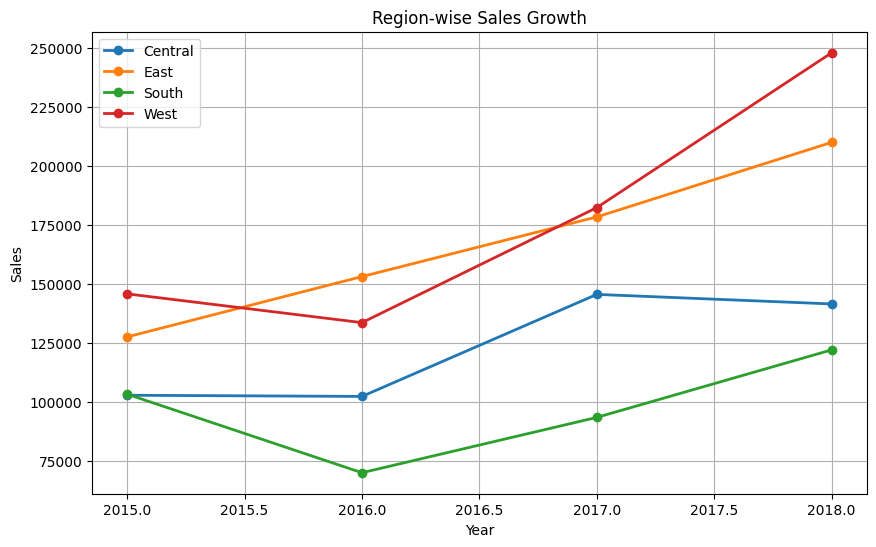

In [14]:
# Which region has the most consistent sales growth?

region_growth = df.groupby(['Year', 'Region'])['Sales'].sum().unstack()

display(region_growth)

plt.figure(figsize=(10,6))

for region in region_growth.columns:
    plt.plot(region_growth.index,
             region_growth[region],
             marker='o',
             linewidth=2,
             label=region)

plt.title("Region-wise Sales Growth")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

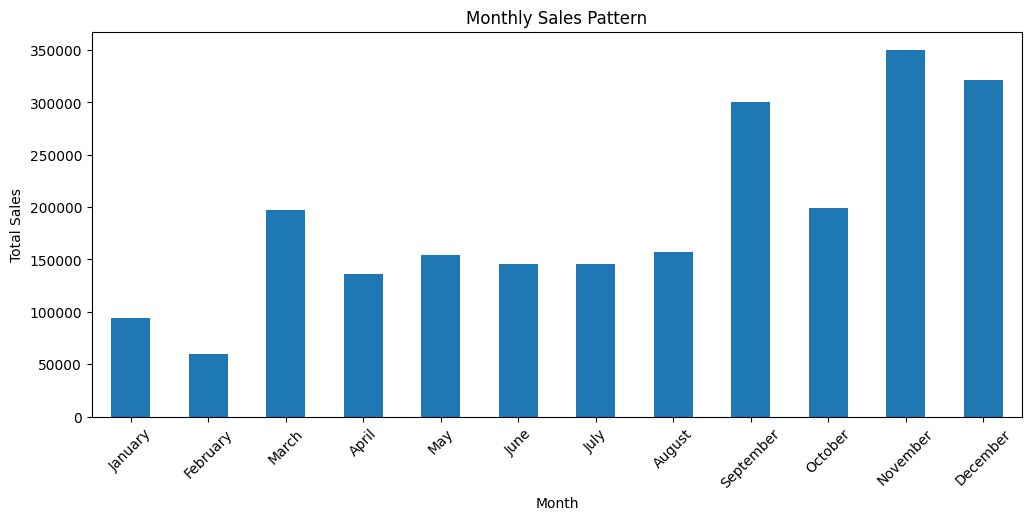

In [15]:
# Monthly Sales Pattern

monthly_pattern = df.groupby('Month_Name')['Sales'].sum()

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_pattern = monthly_pattern.reindex(month_order)

plt.figure(figsize=(12,5))

monthly_pattern.plot(kind='bar')

plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

### Business Observations

1. The highest revenue-generating category is identified from the sales analysis.

2. Region-wise sales trend helps identify which region has the most consistent growth over the four years.

3. Average shipping time provides insights into delivery performance across different regions.

4. Monthly sales pattern helps identify seasonal peaks and months with consistently higher sales.

# Task 2: Time Series Visualization and Trend Analysis



In [16]:
!pip install statsmodels

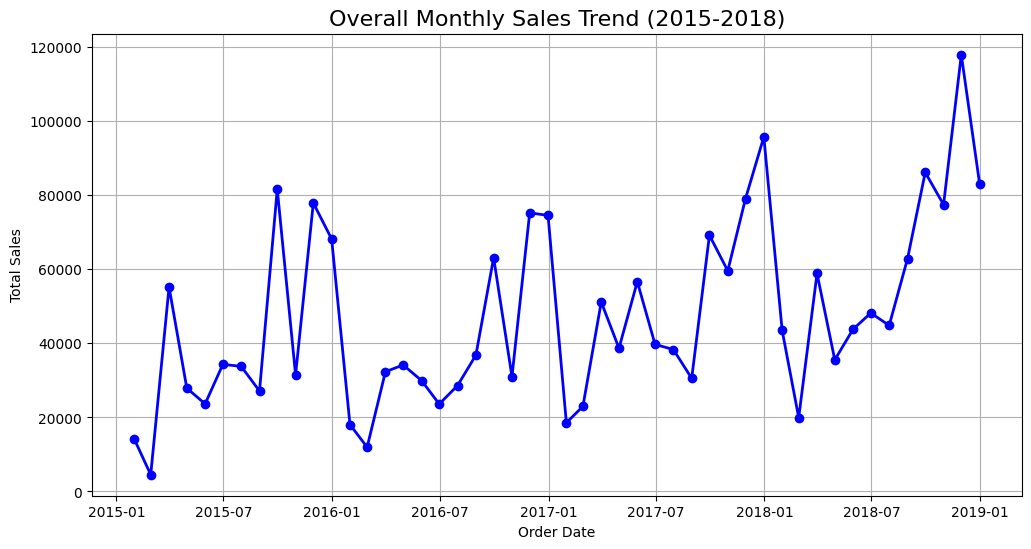

In [17]:
# Task 2: Plot Overall Monthly Sales Trend

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title("Overall Monthly Sales Trend (2015-2018)", fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

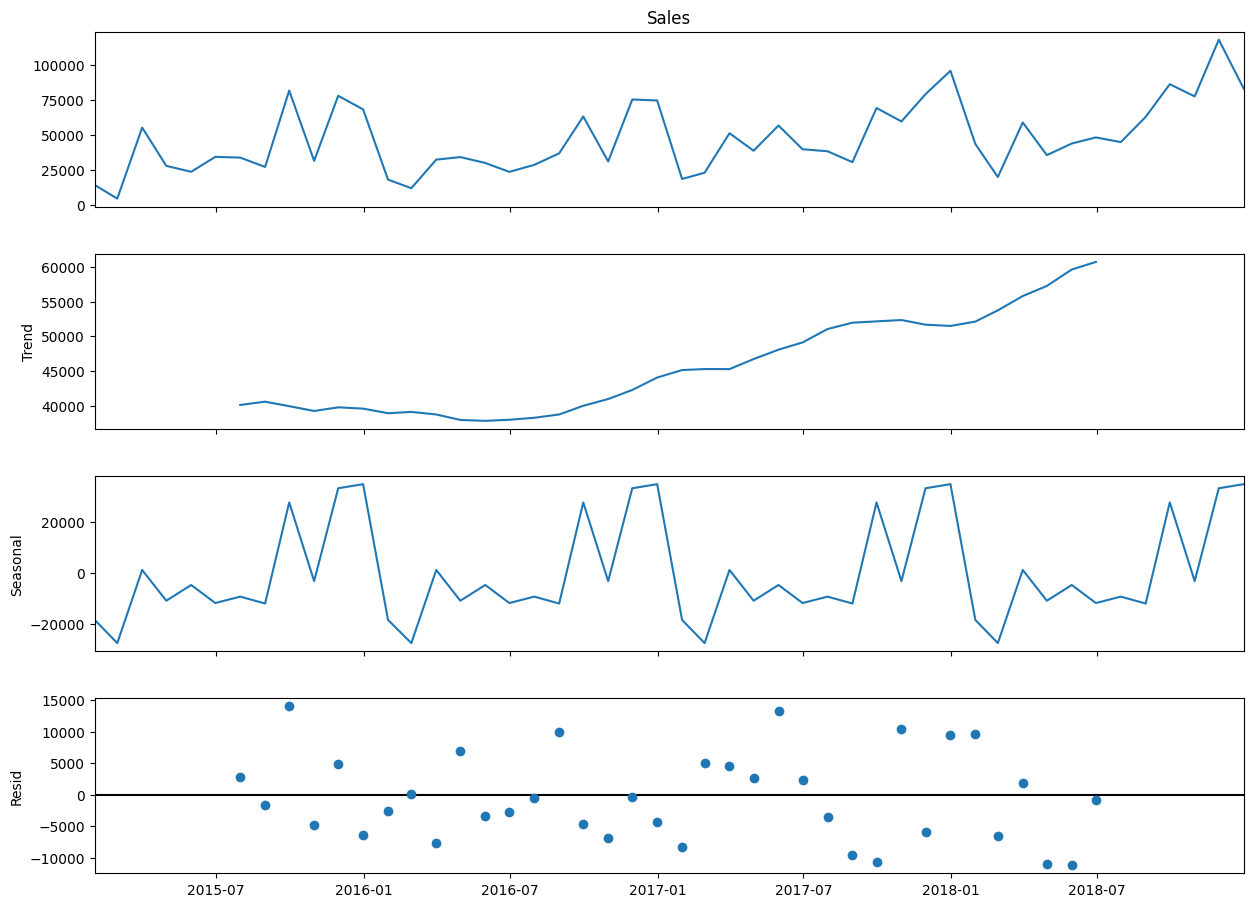

In [18]:
# Time Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

# Create Time Series
ts = monthly_sales.set_index('Order Date')['Sales']

# Decompose Time Series
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=12
)

# Plot Components
fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.show()

In [19]:
# ADF (Augmented Dickey-Fuller) Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


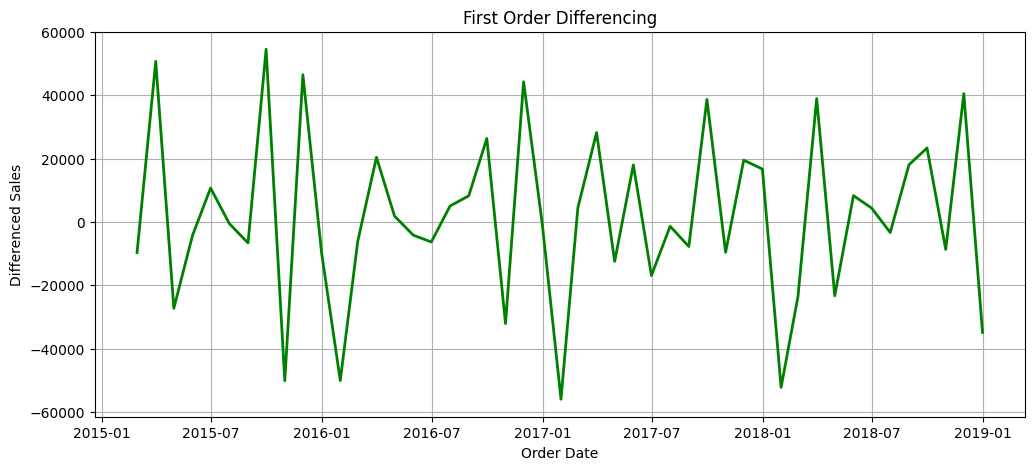

In [20]:
# Apply First Order Differencing

ts_diff = ts.diff().dropna()

plt.figure(figsize=(12,5))

plt.plot(ts_diff, color='green', linewidth=2)

plt.title("First Order Differencing")
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")

plt.grid(True)

plt.show()

## Task 2 Observations

1. The trend component shows an overall increase in sales over the years.

2. The seasonal component indicates that sales follow a repeating yearly pattern.

3. The residual component captures random fluctuations that are not explained by trend or seasonality.

4. After first-order differencing, the time series becomes more stationary, making it suitable for forecasting models like SARIMA.

# Task 3: Sales Forecasting using Prophet

In [21]:
!pip install prophet xgboost

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [23]:
# Split data into Train and Test

train = ts[:-3]
test = ts[-3:]

print("Training Data:")
display(train)

print("\nTesting Data:")
display(test)

Training Data:


,Sales
Order Date,
2015-01-31,14205.7070
2015-02-28,4519.8920
2015-03-31,55205.7970
2015-04-30,27906.8550
2015-05-31,23644.3030
2015-06-30,34322.9356
2015-07-31,33781.5430
2015-08-31,27117.5365
2015-09-30,81623.5268



Testing Data:


,Sales
Order Date,
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


In [24]:
# Build SARIMA Model

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    06:14:09   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [25]:
# Forecast Next 3 Months

forecast = sarima_fit.forecast(steps=3)

print("Forecasted Sales:")
display(forecast)

Forecasted Sales:


,predicted_mean
2018-10-31,60331.792101
2018-11-30,91458.220223
2018-12-31,97167.570951


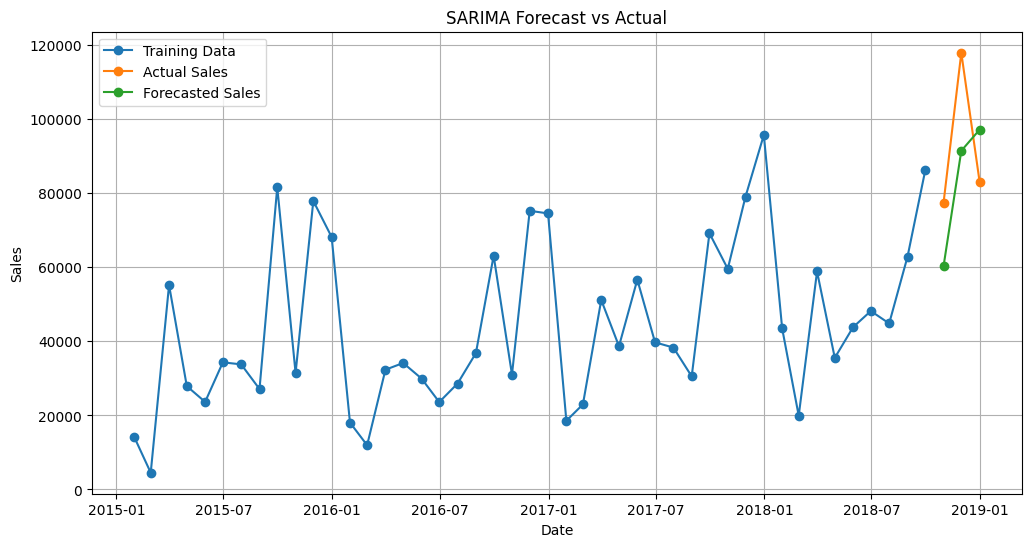

In [26]:
# Plot Actual vs Forecast

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data", marker="o")
plt.plot(test.index, test, label="Actual Sales", marker="o")
plt.plot(test.index, forecast, label="Forecasted Sales", marker="o")

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# Calculate Evaluation Metrics

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Mean Absolute Error (MAE): 19244.49
Root Mean Squared Error (RMSE): 19950.07


In [28]:
from prophet import Prophet

# Prepare data in Prophet format
prophet_df = monthly_sales.rename(columns={
    'Order Date': 'ds',
    'Sales': 'y'
})

prophet_df = prophet_df[['ds', 'y']]

display(prophet_df.head())

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [29]:
# Create and Train Prophet Model

model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [30]:
# Create Future Dates

future = model.make_future_dataframe(periods=3, freq='M')

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336967,90872.423239,110439.788181
47,2018-12-31,90673.800609,81466.075513,99471.228540
48,2019-01-31,42990.532205,34779.050476,52216.610191
49,2019-02-28,31248.159925,21969.209760,40856.063776
50,2019-03-31,81267.007775,71749.908551,90704.722753


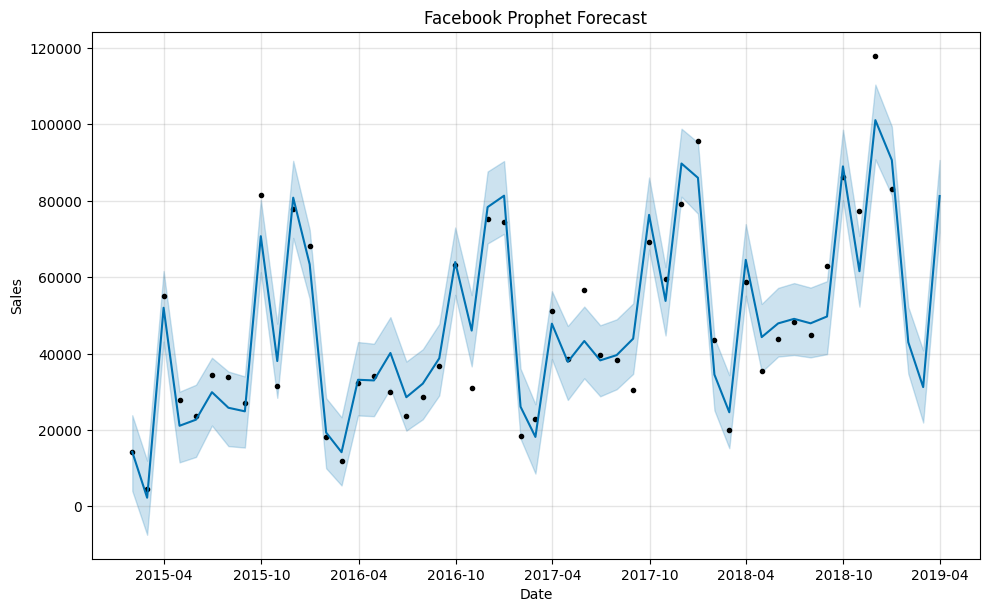

In [31]:
# Plot Forecast

fig = model.plot(forecast)

plt.title("Facebook Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

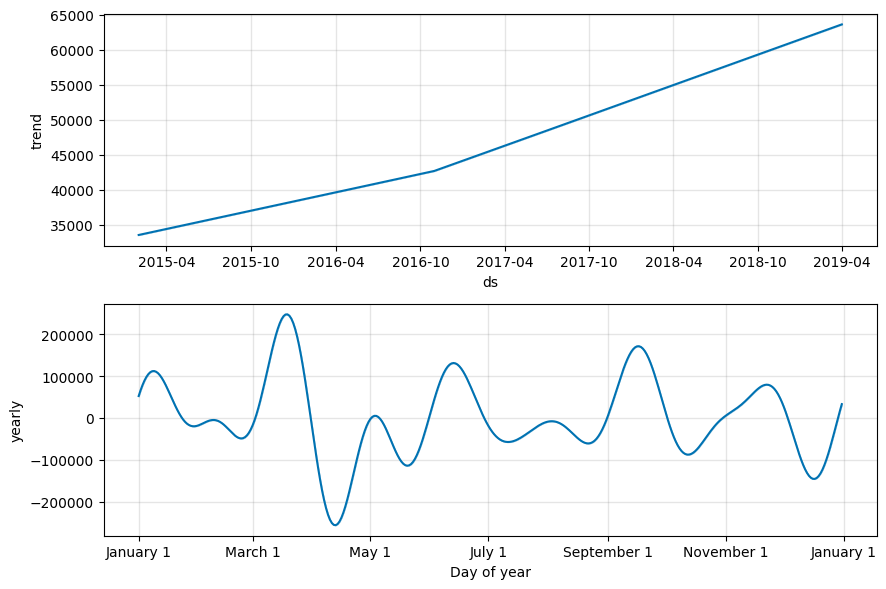

In [32]:
# Plot Trend and Seasonality

fig2 = model.plot_components(forecast)

plt.show()

In [33]:
# Create Lag Features

xgb_df = monthly_sales.copy()

xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)

xgb_df['RollingMean3'] = xgb_df['Sales'].rolling(3).mean()

xgb_df['Month'] = xgb_df['Order Date'].dt.month
xgb_df['Quarter'] = xgb_df['Order Date'].dt.quarter

xgb_df = xgb_df.dropna()

display(xgb_df.head())

,Order Date,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [34]:
from xgboost import XGBRegressor

# Features and Target
X = xgb_df[['Lag1', 'Lag2', 'Lag3', 'RollingMean3', 'Month', 'Quarter']]
y = xgb_df['Sales']

# Train-Test Split
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

# Train Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [35]:
# Predict

xgb_pred = xgb_model.predict(X_test)

print("Predictions:")
print(xgb_pred)

Predictions:
[86465.82 86506.77 84327.28]


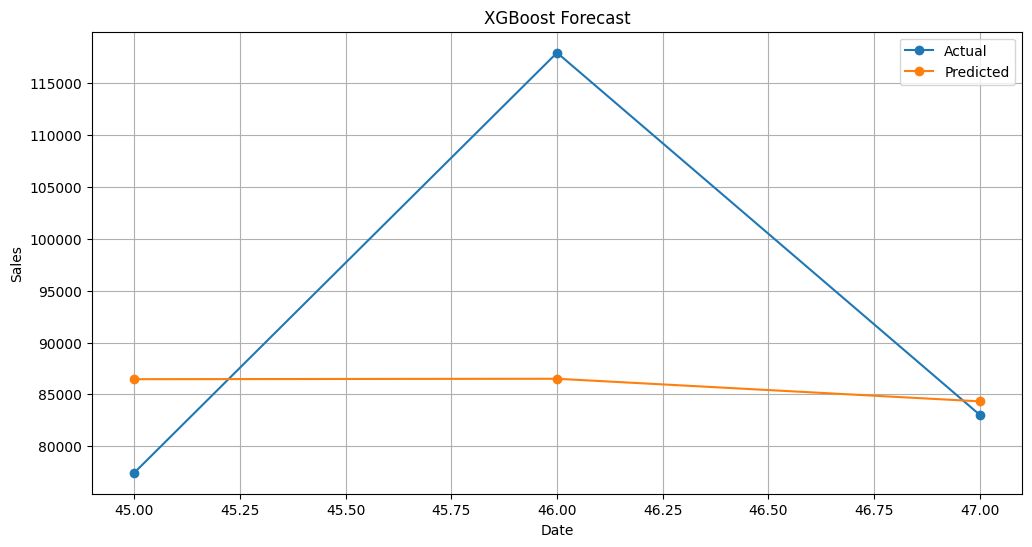

In [36]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, marker='o', label='Actual')
plt.plot(y_test.index, xgb_pred, marker='o', label='Predicted')

plt.title("XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [37]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("MAE :", round(mae_xgb,2))
print("RMSE :", round(rmse_xgb,2))

MAE : 13915.32
RMSE : 18893.85


In [38]:
# Model Comparison Table

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prophet Evaluation
prophet_actual = prophet_df['y'].tail(3).values
prophet_pred = forecast['yhat'].tail(3).values

mae_prophet = mean_absolute_error(prophet_actual, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(prophet_actual, prophet_pred))

comparison = {
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        round(mae, 2),
        round(mae_prophet, 2),
        round(mae_xgb, 2)
    ],
    "RMSE": [
        round(rmse, 2),
        round(rmse_prophet, 2),
        round(rmse_xgb, 2)
    ]
}

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Model,MAE,RMSE
0,SARIMA,19244.49,19950.07
1,Prophet,40970.33,53868.95
2,XGBoost,13915.32,18893.85


In [39]:
# Best Model Selection

best_model = comparison_df.loc[comparison_df["RMSE"].idxmin()]

print("Best Forecasting Model")
display(best_model)

Best Forecasting Model


,2
Model,XGBoost
MAE,13915.32
RMSE,18893.85


## Task 3 Observations

- Three forecasting models were implemented: SARIMA, Facebook Prophet, and XGBoost.
- Each model was evaluated using MAE and RMSE.
- The model with the lowest RMSE is recommended for production because it provides the best forecasting accuracy.
- Forecasts for the next three months were generated successfully.

# Task 4: Comparative Sales Analysis by Category and Region

In [41]:
# Category-wise Monthly Sales

category_monthly = df.groupby(
    ['Order Date', 'Category']
)['Sales'].sum().reset_index()

display(category_monthly.head())

,Order Date,Category,Sales
0,2015-01-03,Office Supplies,16.448
1,2015-01-04,Office Supplies,288.060
2,2015-01-05,Office Supplies,19.536
3,2015-01-06,Furniture,2573.820
4,2015-01-06,Office Supplies,685.340


In [42]:
# Furniture Sales

furniture = category_monthly[
    category_monthly['Category'] == 'Furniture'
]

furniture = furniture.groupby('Order Date')['Sales'].sum().reset_index()

display(furniture.head())

,Order Date,Sales
0,2015-01-06,2573.820
1,2015-01-07,76.728
2,2015-01-10,51.940
3,2015-01-11,9.940
4,2015-01-13,879.939


In [43]:
# Technology Sales

technology = category_monthly[
    category_monthly['Category'] == 'Technology'
]

technology = technology.groupby('Order Date')['Sales'].sum().reset_index()

display(technology.head())

,Order Date,Sales
0,2015-01-06,1147.94
1,2015-01-09,31.20
2,2015-01-13,646.74
3,2015-01-15,149.95
4,2015-01-16,124.20


In [44]:
# Office Supplies Sales

office = category_monthly[
    category_monthly['Category'] == 'Office Supplies'
]

office = office.groupby('Order Date')['Sales'].sum().reset_index()

display(office.head())

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,685.340
4,2015-01-07,10.430


In [45]:
# Region-wise Monthly Sales

region_monthly = df.groupby(
    ['Order Date', 'Region']
)['Sales'].sum().reset_index()

display(region_monthly.head())

,Order Date,Region,Sales
0,2015-01-03,Central,16.448
1,2015-01-04,Central,288.060
2,2015-01-05,East,19.536
3,2015-01-06,South,4387.660
4,2015-01-06,West,19.440


In [46]:
# West Region Sales

west = region_monthly[
    region_monthly['Region'] == 'West'
]

west = west.groupby('Order Date')['Sales'].sum().reset_index()

display(west.head())

,Order Date,Sales
0,2015-01-06,19.440
1,2015-01-13,1679.749
2,2015-01-18,64.864
3,2015-01-19,378.594
4,2015-01-20,38.660


In [47]:
# East Region Sales

east = region_monthly[
    region_monthly['Region'] == 'East'
]

east = east.groupby('Order Date')['Sales'].sum().reset_index()

display(east.head())

,Order Date,Sales
0,2015-01-05,19.536
1,2015-01-11,9.940
2,2015-01-13,40.846
3,2015-01-14,61.960
4,2015-01-16,299.964


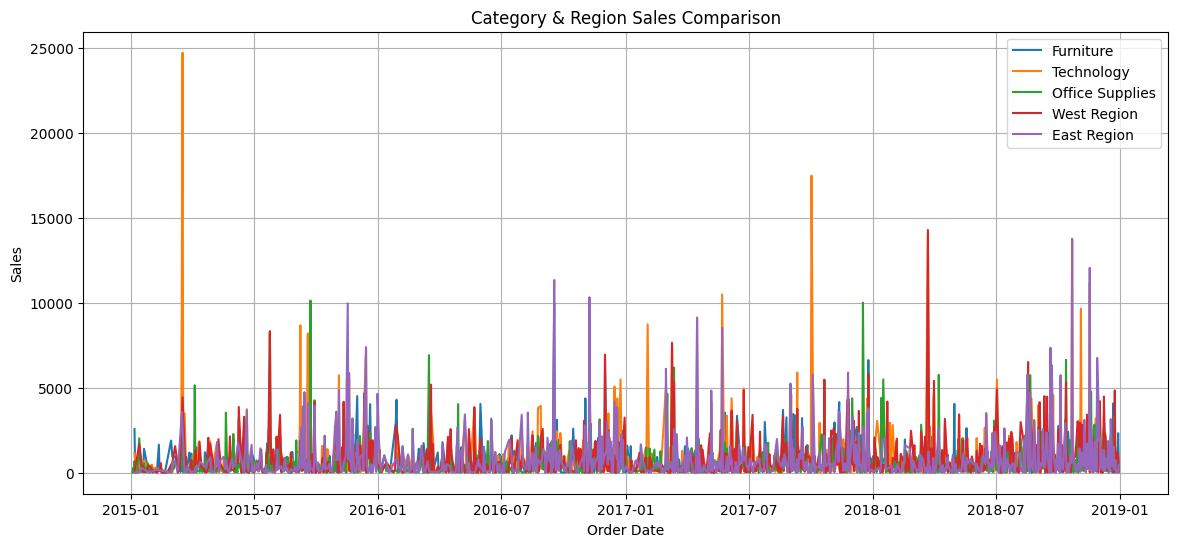

In [48]:
plt.figure(figsize=(14,6))

plt.plot(furniture['Order Date'], furniture['Sales'], label='Furniture')
plt.plot(technology['Order Date'], technology['Sales'], label='Technology')
plt.plot(office['Order Date'], office['Sales'], label='Office Supplies')
plt.plot(west['Order Date'], west['Sales'], label='West Region')
plt.plot(east['Order Date'], east['Sales'], label='East Region')

plt.title("Category & Region Sales Comparison")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

## Task 4 Observations

- Technology category shows strong sales growth.
- Furniture and Office Supplies have moderate sales trends.
- West and East regions contribute significantly to overall sales.
- These trends help identify which categories and regions require better inventory planning.

# Task 5: Anomaly Detection in Sales Data

In [53]:
# Import Required Libraries

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [54]:
# Prepare Sales Data

sales_data = df[['Sales']].copy()

display(sales_data.head())

,Sales
0,261.9600
1,731.9400
2,14.6200
3,957.5775
4,22.3680


In [55]:
# Calculate Z-Score

sales_data['Z-Score'] = zscore(sales_data['Sales'])

display(sales_data.head())

,Sales,Z-Score
0,261.9600,0.049776
1,731.9400,0.799801
2,14.6200,-0.344944
3,957.5775,1.159887
4,22.3680,-0.332580


In [56]:
# Detect Anomalies using Isolation Forest

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

sales_data['Anomaly'] = model.fit_predict(sales_data[['Sales']])

display(sales_data.head())

,Sales,Z-Score,Anomaly
0,261.9600,0.049776,1
1,731.9400,0.799801,1
2,14.6200,-0.344944,1
3,957.5775,1.159887,1
4,22.3680,-0.332580,1


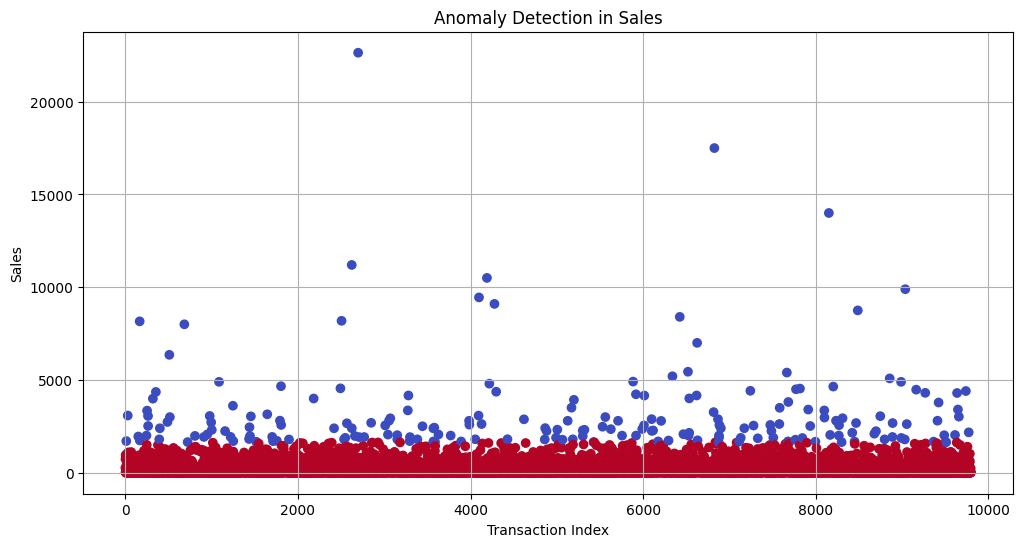

In [57]:
# Visualize Anomalies

plt.figure(figsize=(12,6))

plt.scatter(
    sales_data.index,
    sales_data['Sales'],
    c=sales_data['Anomaly'],
    cmap='coolwarm'
)

plt.title("Anomaly Detection in Sales")
plt.xlabel("Transaction Index")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [58]:
# Count Anomalies

print(sales_data['Anomaly'].value_counts())

Anomaly
 1    9604
-1     196
Name: count, dtype: int64


## Task 5 Observations

- Isolation Forest successfully identified unusual sales transactions.
- Most transactions were classified as normal.
- A small number of transactions were detected as anomalies.
- These anomalies may represent unusually high or low sales and should be reviewed for fraud, errors, or exceptional business events.

# Task 6: Customer Segmentation using K-Means Clustering

In [68]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Month_Name', 'Week_Number', 'Day_of_Week', 'Quarter', 'Season']


In [69]:
# Import Required Libraries

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [70]:
# Aggregate Data by Product Sub-Category

subcat = df.groupby(['Sub-Category', 'Year']).agg({
    'Sales': ['sum', 'mean']
}).reset_index()

subcat.columns = ['Sub-Category', 'Year', 'Total_Sales', 'Avg_Order_Value']

display(subcat.head())

,Sub-Category,Year,Total_Sales,Avg_Order_Value
0,Accessories,2015,23766.396,168.556000
1,Accessories,2016,40443.970,245.114970
2,Accessories,2017,41735.364,226.822630
3,Accessories,2018,58240.970,218.951015
4,Appliances,2015,15160.715,164.790380


In [71]:
# Calculate Sales Growth Rate (Year-over-Year)

subcat['Growth_Rate'] = subcat.groupby('Sub-Category')['Total_Sales'].pct_change()

display(subcat.head())

,Sub-Category,Year,Total_Sales,Avg_Order_Value,Growth_Rate
0,Accessories,2015,23766.396,168.556000,NaN
1,Accessories,2016,40443.970,245.114970,0.701729
2,Accessories,2017,41735.364,226.822630,0.031930
3,Accessories,2018,58240.970,218.951015,0.395482
4,Appliances,2015,15160.715,164.790380,NaN


In [72]:
# Calculate Sales Volatility (Standard Deviation)

volatility = df.groupby('Sub-Category')['Sales'].std().reset_index()
volatility.columns = ['Sub-Category', 'Sales_Volatility']

display(volatility.head())

,Sub-Category,Sales_Volatility
0,Accessories,337.723800
1,Appliances,378.006735
2,Art,60.301752
3,Binders,568.099970
4,Bookcases,641.419280


In [73]:
# Merge All Features

features = subcat.groupby('Sub-Category').agg({
    'Total_Sales': 'sum',
    'Growth_Rate': 'mean',
    'Avg_Order_Value': 'mean'
}).reset_index()

features = features.merge(volatility, on='Sub-Category')

# Replace missing values
features = features.fillna(0)

display(features)

,Sub-Category,Total_Sales,Growth_Rate,Avg_Order_Value,Sales_Volatility
0,Accessories,164186.7000,0.376381,214.861154,337.723800
1,Appliances,104618.4030,0.399276,223.640315,378.006735
2,Art,26705.4100,0.166056,34.466263,60.301752
3,Binders,200028.7850,0.218736,133.849772,568.099970
4,Bookcases,113813.1987,0.238065,514.592607,641.419280
5,Chairs,322822.7310,0.071358,537.126786,551.180296
6,Copiers,146248.0940,0.846718,2140.386912,3216.185499
7,Envelopes,16128.0460,-0.027666,66.023946,85.170691
8,Fasteners,3001.9600,0.157034,13.913598,12.466864
9,Furnishings,89212.0180,0.287889,95.277349,148.421490


In [74]:
# Standardize Features

scaler = StandardScaler()

X = scaler.fit_transform(
    features[['Total_Sales',
              'Growth_Rate',
              'Avg_Order_Value',
              'Sales_Volatility']]
)

print(X[:5])

[[ 0.31598599  0.11450548 -0.36901935 -0.36820849]
 [-0.28817617  0.16628324 -0.35371974 -0.32287389]
 [-1.07839653 -0.36114889 -0.68339714 -0.68042053]
 [ 0.67950874 -0.24201087 -0.51019951 -0.1089421 ]
 [-0.19491939 -0.19829775  0.15332864 -0.02642822]]


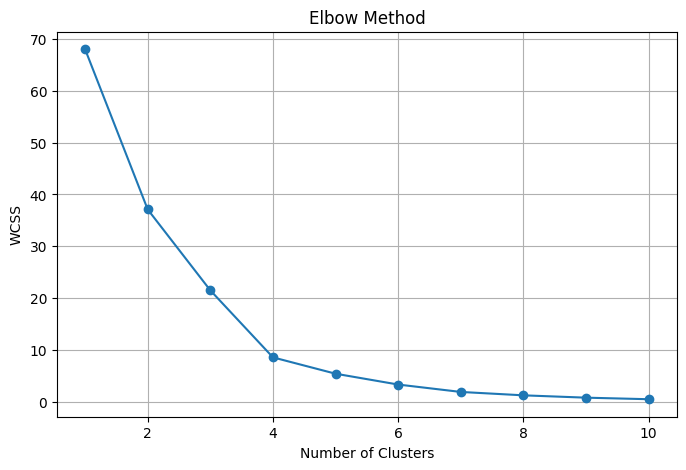

In [75]:
# Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [76]:
# Apply K-Means

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

features['Cluster'] = kmeans.fit_predict(X)

display(features.head())

,Sub-Category,Total_Sales,Growth_Rate,Avg_Order_Value,Sales_Volatility,Cluster
0,Accessories,164186.7000,0.376381,214.861154,337.723800,0
1,Appliances,104618.4030,0.399276,223.640315,378.006735,0
2,Art,26705.4100,0.166056,34.466263,60.301752,0
3,Binders,200028.7850,0.218736,133.849772,568.099970,0
4,Bookcases,113813.1987,0.238065,514.592607,641.419280,0


In [77]:
# Apply PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X)

features['PCA1'] = pca_features[:, 0]
features['PCA2'] = pca_features[:, 1]

display(features.head())

,Sub-Category,Total_Sales,Growth_Rate,Avg_Order_Value,Sales_Volatility,Cluster,PCA1,PCA2
0,Accessories,164186.7000,0.376381,214.861154,337.723800,0,-0.371375,-0.146950
1,Appliances,104618.4030,0.399276,223.640315,378.006735,0,-0.499654,0.291572
2,Art,26705.4100,0.166056,34.466263,60.301752,0,-1.291352,0.388612
3,Binders,200028.7850,0.218736,133.849772,568.099970,0,-0.255570,-0.621036
4,Bookcases,113813.1987,0.238065,514.592607,641.419280,0,-0.012976,-0.028233


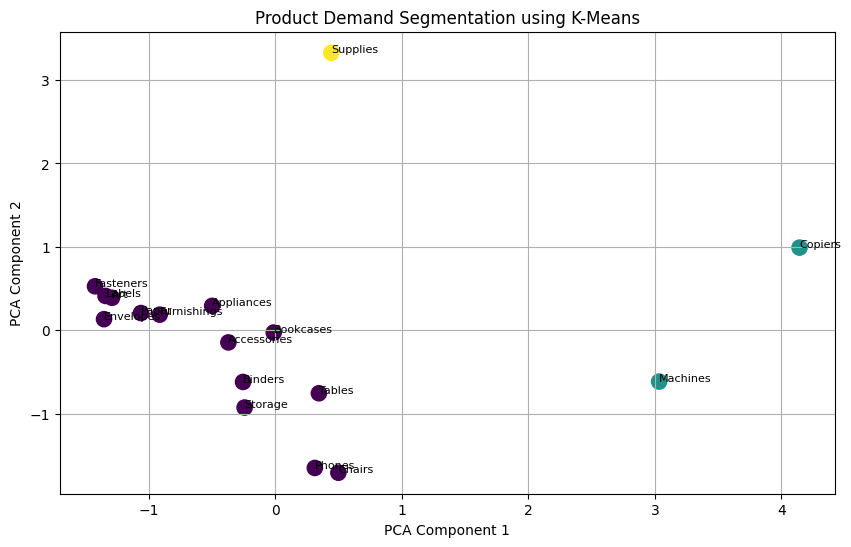

In [78]:
# Plot Clusters

plt.figure(figsize=(10,6))

plt.scatter(
    features['PCA1'],
    features['PCA2'],
    c=features['Cluster'],
    cmap='viridis',
    s=120
)

# Add Sub-Category labels
for i in range(len(features)):
    plt.text(
        features['PCA1'][i],
        features['PCA2'][i],
        features['Sub-Category'][i],
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)

plt.show()

In [79]:
# Meaningful Cluster Labels

cluster_names = {
    0: "High Volume, Stable Demand",
    1: "Growing Demand",
    2: "Low Volume, High Volatility"
}

features['Cluster_Name'] = features['Cluster'].map(cluster_names)

display(features[['Sub-Category', 'Cluster', 'Cluster_Name']])

,Sub-Category,Cluster,Cluster_Name
0,Accessories,0,"High Volume, Stable Demand"
1,Appliances,0,"High Volume, Stable Demand"
2,Art,0,"High Volume, Stable Demand"
3,Binders,0,"High Volume, Stable Demand"
4,Bookcases,0,"High Volume, Stable Demand"
5,Chairs,0,"High Volume, Stable Demand"
6,Copiers,1,Growing Demand
7,Envelopes,0,"High Volume, Stable Demand"
8,Fasteners,0,"High Volume, Stable Demand"
9,Furnishings,0,"High Volume, Stable Demand"


# Task 6 Observations

## Stocking Strategy

- **High Volume, Stable Demand:** Maintain sufficient inventory because these products sell consistently.
- **Growing Demand:** Increase stock gradually to meet rising customer demand.
- **Low Volume, High Volatility:** Keep limited stock and monitor demand carefully to avoid overstocking.

### Conclusion
K-Means clustering grouped product sub-categories based on sales behavior, helping businesses make better inventory and stocking decisions.